In [ ]:
# Install hypertools (run this first on Colab)
%pip install -q "hypertools[interactive]"

# Normalization

The `normalize` function is a helper to z-score your data. This is useful if your features (columns) are scaled differently within or across datasets. By default, hypertools normalizes *across* the columns of all datasets passed, but also affords the option to normalize columns *within* individual lists. Alternatively, you can also normalize each row. The function returns an array or list of arrays where the columns or rows are z-scored. Note that a list containing a single array is returned as a bare array; lists of two or more arrays come back as lists.

## Import packages

In [1]:
import hypertools as hyp
import numpy as np

%matplotlib inline

## Generate synthetic data

First, we generate two sets of synthetic data. We pull points randomly from a multivariate normal distribution for each set, so the sets will exhibit unique statistical properties.

In [2]:
np.random.seed(123)  # seed the RNG so this tutorial is reproducible

x1 = np.random.randn(10,10)
x2 = np.random.randn(10,10)

c1 = np.dot(x1, x1.T)
c2 = np.dot(x2, x2.T)

m1 = np.zeros([1,10])
m2 = 10 + m1

data1 = np.random.multivariate_normal(m1[0], c1, 100)
data2 = np.random.multivariate_normal(m2[0], c2, 100)

data = [data1, data2]

## Visualize the data

`hyp.plot(data, '.')` reduces the 10 columns to the top 3 principal components before drawing, so the two visibly offset clouds below reflect the different means and covariances we simulated above.

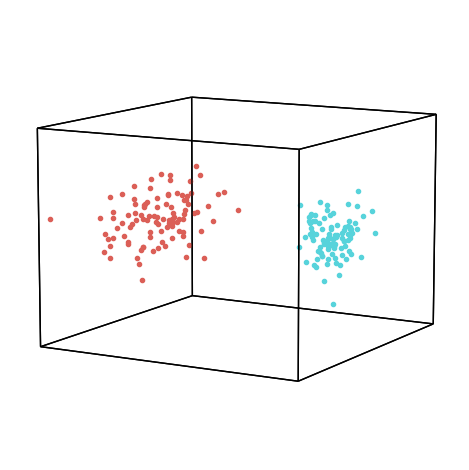

In [3]:
fig = hyp.plot(data, '.')

## Normalizing (Specified Cols or Rows)

By default, calling `hyp.normalize(data)` z-scores the columns across all passed lists (equivalent to passing `normalize='across'`). To specify a different normalization, pass one of the following arguments as a string, as shown in the examples below.

+ 'across' - columns z-scored across passed lists (default)
+ 'within' - columns z-scored within passed lists
+ 'row' - rows z-scored 

### Normalizing 'across'

When you normalize 'across', all of the data is stacked/combined, and the normalization is done on the columns of the full dataset. Then the data is split back into separate elements.

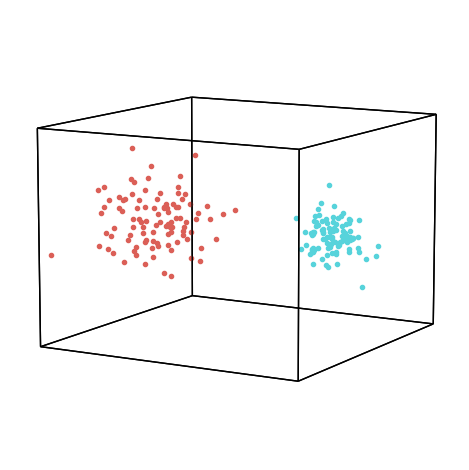

In [4]:
norm = hyp.normalize(data, normalize = 'across')
fig = hyp.plot(norm, '.')

### Normalizing 'within'

When you normalize 'within', normalization is done on the columns of each element of the data, separately. 

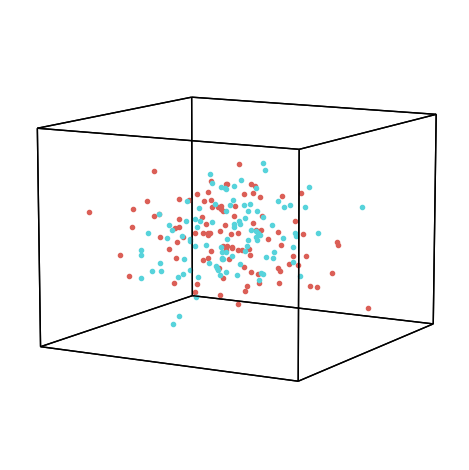

In [5]:
norm = hyp.normalize(data, normalize = 'within')
fig = hyp.plot(norm, '.')

### Normalizing by 'row'

When you normalize by 'row', each observation is z-scored across its own features, which removes that sample's overall offset and scale. This helps when the overall magnitude varies from sample to sample but the pattern across features is what matters.

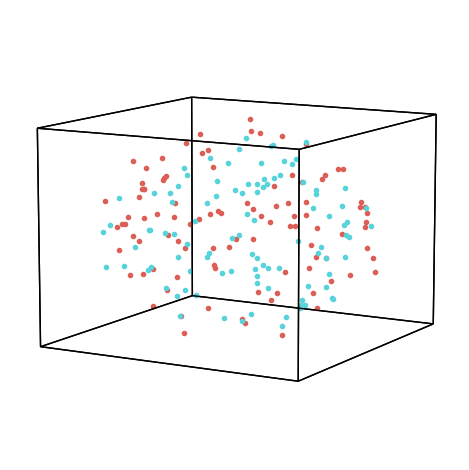

In [6]:
norm = hyp.normalize(data, normalize = 'row')
fig = hyp.plot(norm, '.')